In [53]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from scipy.signal import find_peaks
from scipy.interpolate import interp1d
import os



In [3]:
import pandas as pd


# sipin_path = r"C:\Users\maryl\Documents\Universite\Session_6\tp_biom\exam_lab\Si-PIN_60.30x_Am241_60s_1024.mca"
sipin_path = r"C:\Users\charl\OneDrive\UL\Travaux pratiques PhysMed\Filtration X\TPmedical\spectres_bruts\filtration\Cul_5mils_MiniX_76.70X_4096_40kV_100uA.mca"

with open(sipin_path, "r") as f:
    lines = f.readlines()

# Exemple : garder seulement les lignes numériques
data = []
for line in lines:
    try:
        value = float(line.strip())
        data.append(value)
    except:
        pass


df = pd.DataFrame(data, columns=["Counts"])
df.to_csv(r"C:\Users\charl\OneDrive\UL\Travaux pratiques PhysMed\Filtration X\TPmedical\csv\attenuation\Cu_5mils.csv", index=False)

[ 0.  0.  0. ... 16. 27. 32.]


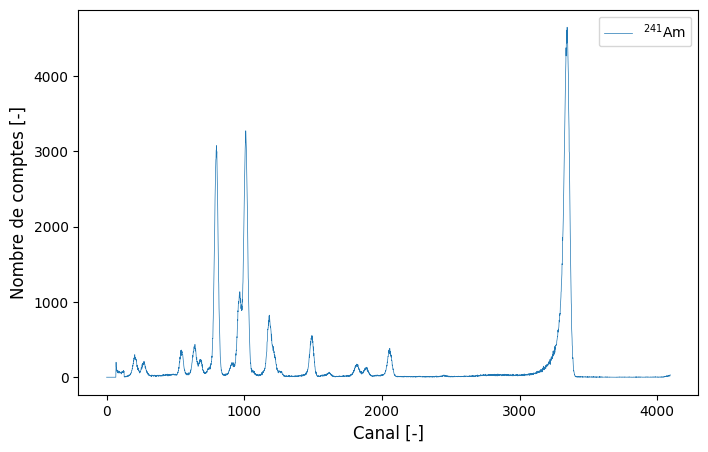

In [4]:
df = pd.read_csv('csv\Am241_76.70X_4096_etalonnage1.csv')
Am241 = df.to_numpy().ravel()
print(Am241)


fig, ax = plt.subplots(figsize=(8,5))
ax.plot(range(4096), Am241, lw=0.5, label=r"$^{241}$Am")
ax.legend()
ax.set_xlabel("Canal [-]", size=12)
ax.set_ylabel("Nombre de comptes [-]", size=12)
plt.show()

[ 796  798 1009 1011 3338 3343 3346 3348]


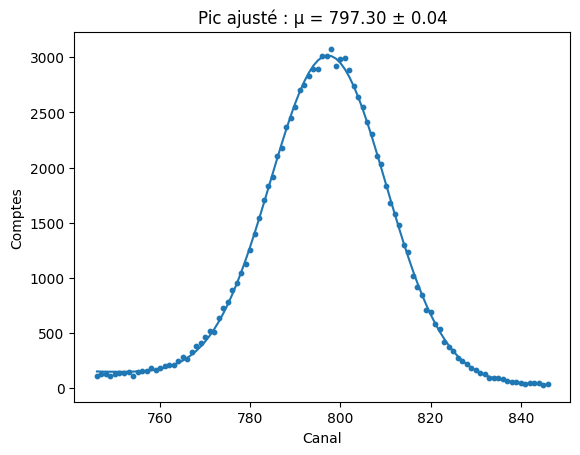

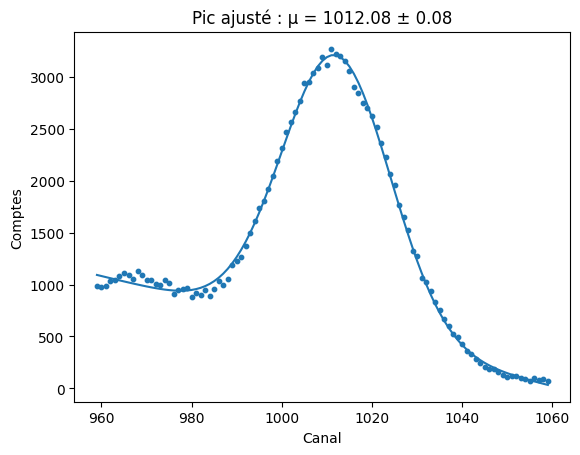

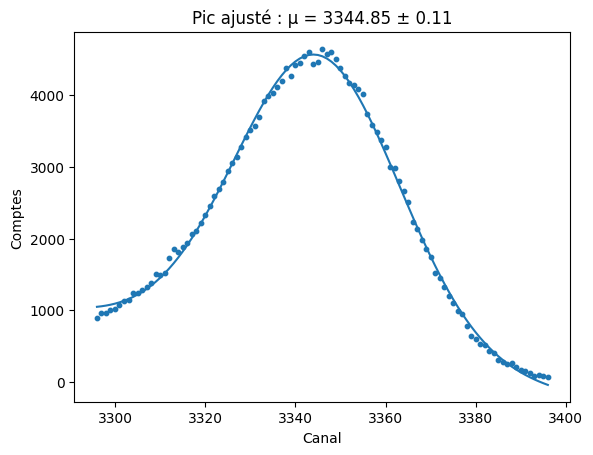

In [5]:
# Modèle gaussienne + fond linéaire
def gaussian_with_background(x, A, mu, sigma, m, c):
    return A * np.exp(-(x - mu)**2 / (2 * sigma**2)) + m*x + c


def fit_peak(counts, peak_center, window=30, plot=True):
    """
    counts : array numpy des comptes
    peak_center : estimation approximative du pic
    window : nombre de canaux autour du pic
    """

    # Définition de la région de fit
    x_min = peak_center - window
    x_max = peak_center + window
    
    x = np.arange(len(counts))
    mask = (x >= x_min) & (x <= x_max)

    x_fit = x[mask]
    y_fit = counts[mask]

    # Valeurs initiales
    A0 = max(y_fit)
    mu0 = peak_center
    sigma0 = window/3
    m0 = 0
    c0 = min(y_fit)

    p0 = [A0, mu0, sigma0, m0, c0]

    # Fit
    popt, pcov = curve_fit(gaussian_with_background, x_fit, y_fit, p0=p0)

    A, mu, sigma, m, c = popt
    mu_err = np.sqrt(np.diag(pcov))[1]
    sigma_err = np.sqrt(np.diag(pcov))[2]

    # Nombre de compte dans le pic
    N_pic = A*sigma*np.sqrt(2*np.pi)


    if plot:
        plt.figure()
        plt.scatter(x_fit, y_fit, s=10)
        plt.plot(x_fit, gaussian_with_background(x_fit, *popt))
        plt.title(f"Pic ajusté : μ = {mu:.2f} ± {mu_err:.2f}")
        plt.xlabel("Canal")
        plt.ylabel("Comptes")
        plt.show()

    return mu, mu_err, sigma, sigma_err, N_pic


peaks, _ = find_peaks(Am241, height=3000)  # ajuster height
print(peaks)

mu_Am1, mu_err_Am1, sigma_Am1, sigma_err_Am1, _ = fit_peak(Am241, peak_center=796, window=50)

mu_Am2, mu_err_CAm2, sigma_Am2, sigma_err_Am2, _ = fit_peak(Am241, peak_center=1009, window=50)

mu_Am3, mu_err_Am3, sigma_Am3, sigma_err_Am3, _ = fit_peak(Am241, peak_center=3346, window=50)


# Étalonnage

Gain (keV/canal) = 0.017905141963904726
Offset (keV) = -0.35239275479242


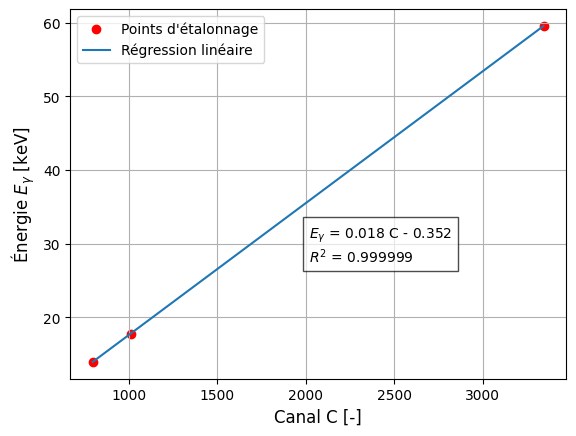

In [54]:
# Étalonnage

channels = np.array([mu_Am1, mu_Am2, mu_Am3])
energies = np.array([13.95, 17.74, 59.54])


coeff = np.polyfit(channels, energies, 1)

a = coeff[0]
b = coeff[1]

print("Gain (keV/canal) =", a)
print("Offset (keV) =", b)  


def etalon(channel):
    return a * channel + b

# Calcul de R^2
ss_res = np.sum((energies - etalon(channels))**2)
ss_tot = np.sum((energies - np.mean(energies))**2)
r2 = 1 - ss_res/ss_tot


plt.scatter(channels, energies, label="Points d'étalonnage", color='red')
plt.plot(channels, etalon(channels), label="Régression linéaire")


# Calcul du point milieu
x_mid = np.mean(channels)
y_mid = a * x_mid + b

# Affichage équation sur le graphe
plt.text(x_mid+300,
         y_mid-3,
         r"$E_\gamma$"+f" = {a:.3f} C - {np.abs(b):.3f}\n$R^2$ = {r2:.6f}",
         fontsize=10,
         bbox=dict(facecolor='white', alpha=0.7))

plt.xlabel("Canal C [-]", size=12)
plt.ylabel(r"Énergie $E_\gamma$ [keV]", size=12)
plt.legend(loc="best")
plt.grid()


plt.show()

# Filtres 

In [39]:
df = pd.read_csv(r'csv\sec_efficace\Ag_1mils.csv')
Ag_1mils = df.to_numpy().ravel()

df = pd.read_csv(r'csv\sec_efficace\Al_10mils.csv')
Al_10mils = df.to_numpy().ravel()

df = pd.read_csv(r'csv\sec_efficace\Cu_2mils.csv')
Cu_2mils = df.to_numpy().ravel()

df = pd.read_csv(r'csv\sec_efficace\Mo_1mils.csv')
Mo_1mils = df.to_numpy().ravel()

df = pd.read_csv(r'csv\sec_efficace\W_1mils.csv')
W_1mils = df.to_numpy().ravel()

df = pd.read_csv(r'csv\sec_efficace\no_filter.csv')
no_filter = df.to_numpy().ravel()

df = pd.read_csv(r'csv\sec_efficace\no_filter_90.csv')
no_filter_90 = df.to_numpy().ravel()


4096
(4096,)
0.03301645238622055
0.0370166648119625
0.0521406156486275
0.021577312728201264
0.021999786283800685
0.02556734912841048
[0.01490661 0.62236961] [ 0.07453449 22.78274398]


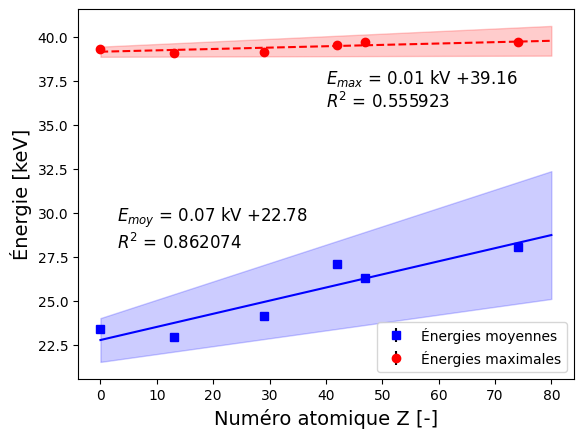

In [89]:
def find_energie_max(energies, counts, threshold=5):#3 pour tension, 8 pour courant
    # masque > seuil de bruit
    mask = counts > threshold
    # Indice du dernier point qui dépasse le seuil
    indices = np.where(mask)[0]

    idx_max = indices[-1]
    return energies[idx_max]

def droite(x, a, b):
    return (a*x)+b

def constante(x, k):
    return k*np.ones(len(x))


filtres = np.array([no_filter, Al_10mils, Cu_2mils, Mo_1mils, Ag_1mils, W_1mils])
t_acqu = np.array([30, 90, 120, 30, 30, 30])
#filtres_norm = filtres / t_acqu

energies_moy = []
i_energies_moy = []
energies_max = []
i_energies_moy = []

energie = etalon(np.arange(4096))
print(len(energie))
print(np.shape(energie))
diff_energies = np.mean(np.diff(energie))

for filtre in filtres:
    energie_moy = np.average(energie, weights=filtre)
    energies_moy.append(energie_moy)

    i_energie_moy = np.sqrt(np.sum(filtre*(energie-energie_moy)**2)/((np.sum(filtre))**2))
    print(i_energie_moy)
    i_energies_moy.append(i_energie_moy)


    energie_max = find_energie_max(energie, filtre)
    energies_max.append(energie_max)
    

Z = np.array([0, 13, 29, 42, 47, 74]) 
popt_moy, pcov_moy = curve_fit(droite, Z, energies_moy)
popt_max, pcov_max = curve_fit(droite, Z, energies_max)
x=np.linspace(0, 80, 1000)
plt.plot(x, droite(x, popt_moy[0], popt_moy[1]), color="blue", linestyle="-")
plt.plot(x, droite(x, popt_max[0], popt_max[1]), color="red", linestyle="--")
i_moy = np.diag(pcov_moy)**0.5
i_max = np.diag(pcov_max)**0.5
print(i_moy, popt_moy)
droite_min_moy = (popt_moy[0]-(2*i_moy[0]))*x + (popt_moy[1]-2*i_moy[1])
droite_max_moy = (popt_moy[0]+(2*i_moy[0]))*x + (popt_moy[1]+2*i_moy[1])
droite_min_max = (popt_max[0]-(2*i_max[0]))*x + (popt_max[1]-2*i_max[1])
droite_max_max = (popt_max[0]+(2*i_max[0]))*x + (popt_max[1]+2*i_max[1])
erreur_test = (diff_energies*np.ones(len(i_energies_moy)))


# Calcul de R^2
ss_res = np.sum((energies_moy - droite(Z, popt_moy[0], popt_moy[1]))**2)
ss_tot = np.sum((energies_moy - np.mean(energies_moy))**2)
r2_moy = 1 - ss_res/ss_tot

ss_res = np.sum((energies_max - droite(Z, popt_max[0], popt_max[1]))**2)
ss_tot = np.sum((energies_max - np.mean(energies_max))**2)
r2_max = 1 - ss_res/ss_tot


plt.errorbar(Z, energies_moy, yerr=i_energies_moy, fmt='bs', ecolor = 'black', label = 'Énergies moyennes')
plt.fill_between(x, droite_min_moy, droite_max_moy, alpha=0.2, color="blue")
plt.errorbar(Z, energies_max, yerr=4*erreur_test, fmt='ro', ecolor = 'black', label = 'Énergies maximales')
plt.fill_between(x, droite_min_max, droite_max_max, alpha=0.2, color="red")
plt.legend()
plt.xlabel(r"Numéro atomique Z [-]", fontsize=14)
plt.text(40, 36, r"$E_{max}$"+ f" = {popt_max[0]:.2f} kV +{popt_max[1]:.2f}\n$R^2$ = {r2_max:.6f}", fontsize=12)#
plt.text(3, 28, r"$E_{moy}$"+ f' = {popt_moy[0]:.2f} kV +{popt_moy[1]:.2f}\n$R^2$ = {r2_moy:.6f}', fontsize=12)#
plt.ylabel(r"Énergie [keV]", fontsize=14)
plt.show()

# Section efficace

556.4333333333333
[  94.76666667   58.00833333 1337.96666667  879.33333333 1059.56666667]
[ 1.15646782e-21  5.25750183e-21 -5.39569827e-21 -3.07319522e-21
 -4.01088223e-21]


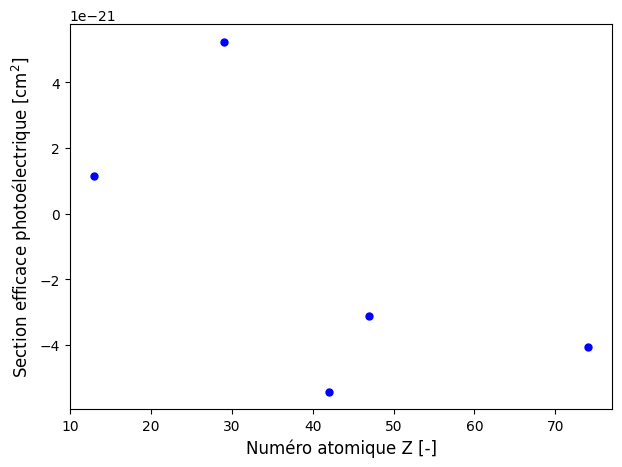

' # CALCUL R²\nFWHM_fit = fwhm_model2(E, a_fit, b_fit)\n#FWHM_fit = fwhm_model2(E, a_fit)\n\nss_res = np.sum((FWHM - FWHM_fit) ** 2)\nss_tot = np.sum((FWHM - np.mean(FWHM)) ** 2)\nR2_fwhm = 1 - ss_res / ss_tot\n\n\nRrel_fit = Rrel_model2(E, c_fit, d_fit)\n\nss_res = np.sum((R - Rrel_fit) ** 2)\nss_tot = np.sum((R - np.mean(R)) ** 2)\nR2_Rrel = 1 - ss_res / ss_tot\n\n\n#print(E)\n#print(E_err)\n\nprint(a_fit, b_fit)\nprint(c_fit, d_fit)\n\nprint(R2_fwhm)\nprint(R2_Rrel)\n'

In [71]:
NA = 6.022e23
mils = 25.4e-4

def sec_eff(N0, Nt, rho, t, A):
    return (-np.log(Nt/N0) * A) / (rho * t * NA) - 0.20 * (A / NA)


# NIST, NIH
A = np.array([26.9815385, 63.546, 95.95, 107.8682, 183.84])
rho = np.array([2.70, 8.933, 10.2, 10.501, 19.3])
t = np.array([10, 2, 1, 1, 1]) * mils


N0 = np.sum(no_filter[1700:1900]) / 30
Nt_Ag = np.sum(Ag_1mils[1700:1900]) / 30
Nt_Al = np.sum(Al_10mils[1700:1900]) / 90
Nt_Cu = np.sum(Cu_2mils[1700:1900]) / 120
Nt_Mo = np.sum(Mo_1mils[1700:1900]) / 30
Nt_W = np.sum(W_1mils[1700:1900]) / 30
Nt = np.array([Nt_Al, Nt_Cu, Nt_Mo, Nt_Ag, Nt_W])
print(N0)
print(Nt)
print((-np.log(Nt/N0))/(rho*t) * (A/NA))



sec_efficace= sec_eff(N0, Nt, rho, t, A)
Z = np.array([13, 29, 42, 47, 74])
     

def model(Z, c, n):
    return c * Z**n

popt_model, _ = curve_fit(model, Z, sec_efficace)
c_fit, n_fit = popt_model


# =============================
# TRACE UNIQUE GRAPHIQUE
# =============================

fig, ax1 = plt.subplots(figsize=(7,5))
Z_fit = np.linspace(min(Z), max(Z), 300)


# FWHM
ax1.errorbar(Z, sec_efficace, fmt='o', ms=5, color="blue")#, label="Données résolution absolue")
#ax1.plot(E_fit, fwhm_model2(E_fit, a_fit, b_fit), color="blue", label=r"Fit: $R_{abs} = 2.45\sqrt{E}-10.10$"+"\n"+r"$\quad\quad R^2=0.99169$")
ax1.set_xlabel("Numéro atomique Z [-]", size=12)
ax1.set_ylabel(r"Section efficace photoélectrique [cm$^2$]", size=12)
#ax1.legend(loc=(0.2,0.77))

plt.show()

#yerr=FWHM_err


""" # CALCUL R²
FWHM_fit = fwhm_model2(E, a_fit, b_fit)
#FWHM_fit = fwhm_model2(E, a_fit)

ss_res = np.sum((FWHM - FWHM_fit) ** 2)
ss_tot = np.sum((FWHM - np.mean(FWHM)) ** 2)
R2_fwhm = 1 - ss_res / ss_tot


Rrel_fit = Rrel_model2(E, c_fit, d_fit)

ss_res = np.sum((R - Rrel_fit) ** 2)
ss_tot = np.sum((R - np.mean(R)) ** 2)
R2_Rrel = 1 - ss_res / ss_tot


#print(E)
#print(E_err)

print(a_fit, b_fit)
print(c_fit, d_fit)

print(R2_fwhm)
print(R2_Rrel)
"""

26.50532019106467
35.45789117301703


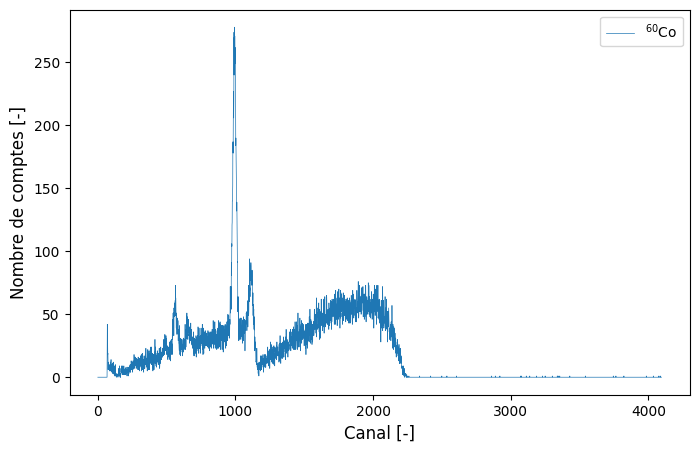

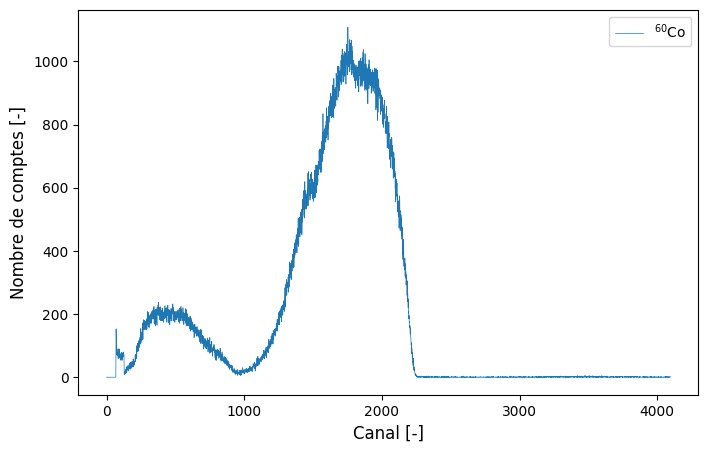

In [9]:
df = pd.read_csv(r'csv\sec_efficace\Mo_V2.csv')
Mo = df.to_numpy().ravel()

df = pd.read_csv(r'csv\sec_efficace\W_V2.csv')
W = df.to_numpy().ravel()



print(etalon(1500))
print(etalon(2000))

fig, ax = plt.subplots(figsize=(8,5))
ax.plot(range(4096), Mo, lw=0.5, label=r"$^{60}$Co")
ax.legend()
ax.set_xlabel("Canal [-]", size=12)
ax.set_ylabel("Nombre de comptes [-]", size=12)
plt.show()

fig, ax = plt.subplots(figsize=(8,5))
ax.plot(range(4096), W, lw=0.5, label=r"$^{60}$Co")
ax.legend()
ax.set_xlabel("Canal [-]", size=12)
ax.set_ylabel("Nombre de comptes [-]", size=12)
plt.show()



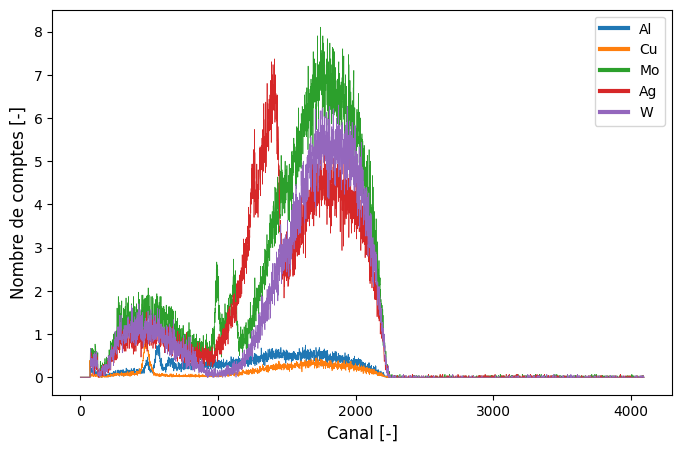

In [10]:

fig, ax = plt.subplots(figsize=(8,5))
ax.plot(range(4096), Al_10mils/90, lw=0.5, label=r"Al")
ax.plot(range(4096), Cu_2mils/120, lw=0.5, label=r"Cu")
ax.plot(range(4096), Mo_1mils/30, lw=0.5, label=r"Mo")
ax.plot(range(4096), Ag_1mils/30, lw=0.5, label=r"Ag")
ax.plot(range(4096), W_1mils/30, lw=0.5, label=r"W")
legend = ax.legend()

for line in legend.get_lines():
    line.set_linewidth(3) 
ax.set_xlabel("Canal [-]", size=12)
ax.set_ylabel("Nombre de comptes [-]", size=12)
plt.show()

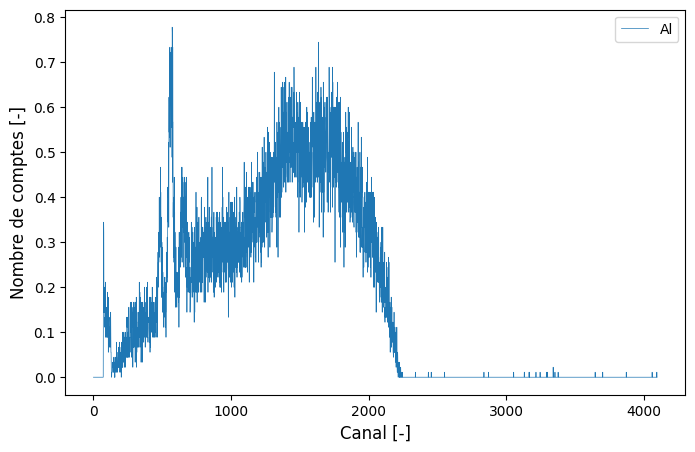

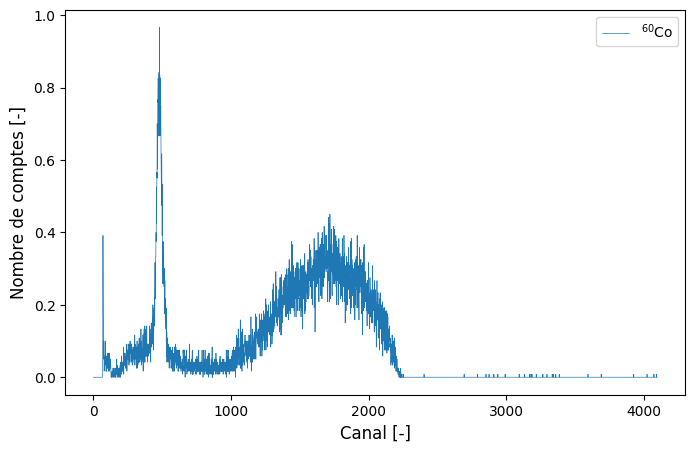

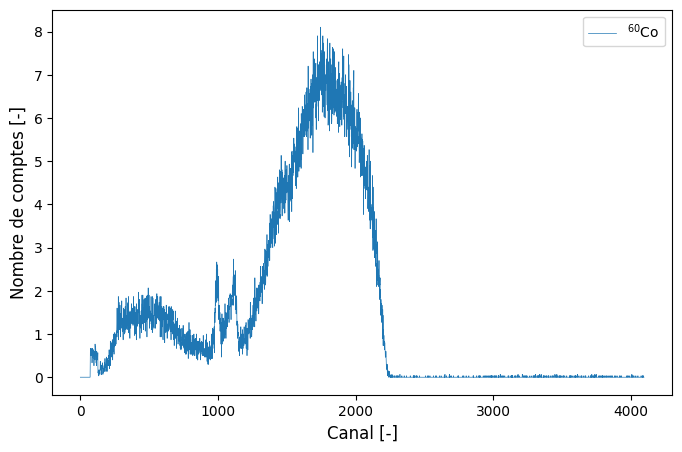

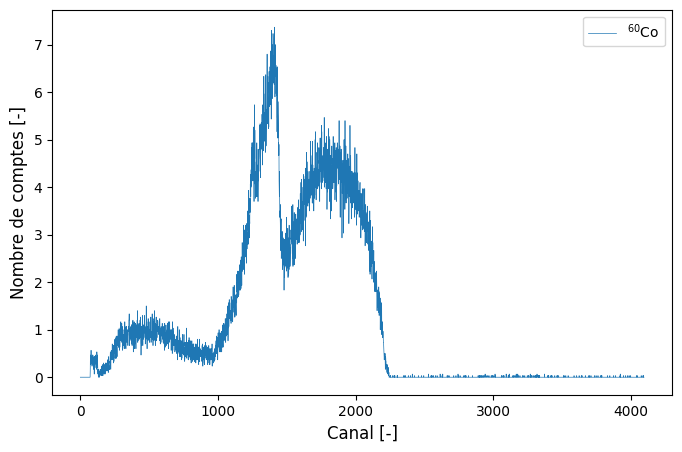

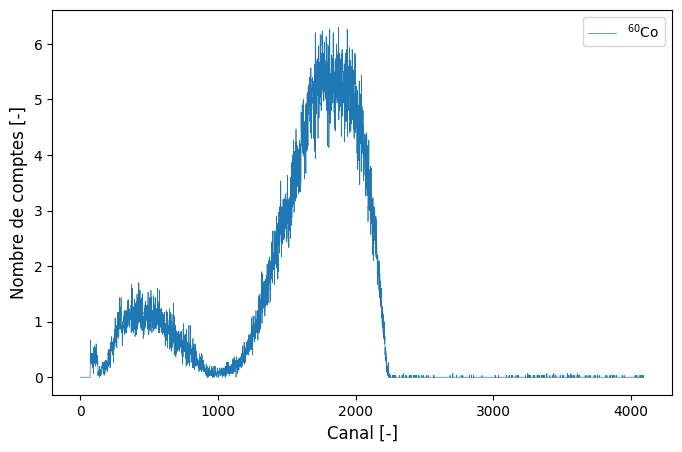

In [11]:

fig, ax = plt.subplots(figsize=(8,5))
ax.plot(range(4096), Al_10mils/90, lw=0.5, label=r"Al")
ax.legend()
ax.set_xlabel("Canal [-]", size=12)
ax.set_ylabel("Nombre de comptes [-]", size=12)
plt.show()

fig, ax = plt.subplots(figsize=(8,5))
ax.plot(range(4096), Cu_2mils/120, lw=0.5, label=r"$^{60}$Co")
ax.legend()
ax.set_xlabel("Canal [-]", size=12)
ax.set_ylabel("Nombre de comptes [-]", size=12)
plt.show()

fig, ax = plt.subplots(figsize=(8,5))
ax.plot(range(4096), Mo_1mils/30, lw=0.5, label=r"$^{60}$Co")
ax.legend()
ax.set_xlabel("Canal [-]", size=12)
ax.set_ylabel("Nombre de comptes [-]", size=12)
plt.show()

fig, ax = plt.subplots(figsize=(8,5))
ax.plot(range(4096), Ag_1mils/30, lw=0.5, label=r"$^{60}$Co")
ax.legend()
ax.set_xlabel("Canal [-]", size=12)
ax.set_ylabel("Nombre de comptes [-]", size=12)
plt.show()

fig, ax = plt.subplots(figsize=(8,5))
ax.plot(range(4096), W_1mils/30, lw=0.5, label=r"$^{60}$Co")
ax.legend()
ax.set_xlabel("Canal [-]", size=12)
ax.set_ylabel("Nombre de comptes [-]", size=12)
plt.show()

# Coefficient d'atténutation

In [12]:
df = pd.read_csv(r'csv\attenuation\Al_10mils.csv')
Al_10mils = df.to_numpy().ravel()

df = pd.read_csv(r'csv\attenuation\Al_20mils.csv')
Al_20mils = df.to_numpy().ravel()

df = pd.read_csv(r'csv\attenuation\Al_30mils.csv')
Al_30mils = df.to_numpy().ravel()

df = pd.read_csv(r'csv\attenuation\Al_40mils.csv')
Al_40mils = df.to_numpy().ravel()

df = pd.read_csv(r'csv\attenuation\Al_80mils.csv')
Al_80mils = df.to_numpy().ravel()


df = pd.read_csv(r'csv\attenuation\Cu_2mils.csv')
Cu_2mils = df.to_numpy().ravel()

df = pd.read_csv(r'csv\attenuation\Cu_3mils.csv')
Cu_3mils = df.to_numpy().ravel()

df = pd.read_csv(r'csv\attenuation\Cu_4mils.csv')
Cu_4mils = df.to_numpy().ravel()

df = pd.read_csv(r'csv\attenuation\Cu_5mils.csv')
Cu_5mils = df.to_numpy().ravel()

0.17905141963904725


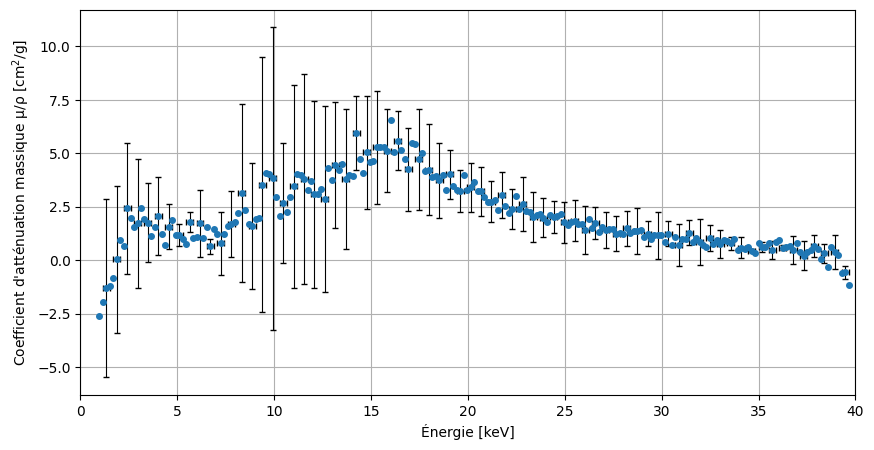

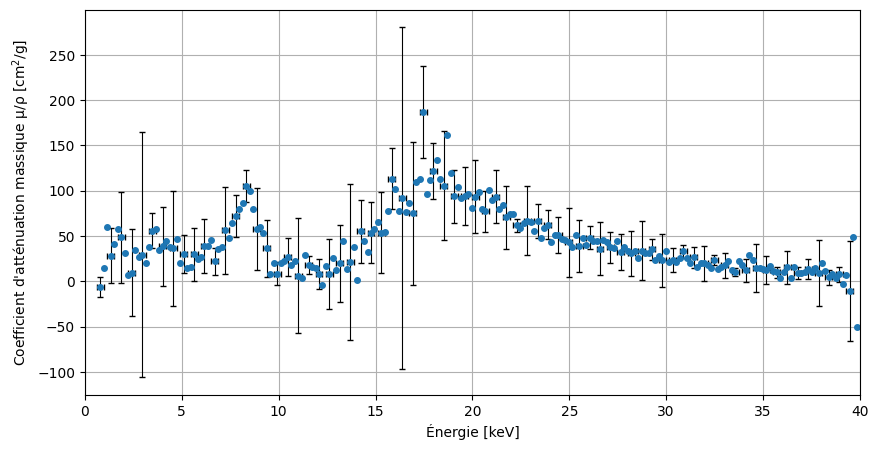

In [56]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

# -----------------------------
# Modèle exponentiel
# -----------------------------
def modele_log(x, lnN0, mu):
    return lnN0 - mu * x

def expo(t, N0, mu):
    return N0 * np.exp(-mu * t)

# -----------------------------
# Données à fournir
# -----------------------------

# épaisseurs en cm 
t_Al = np.array([10, 20, 40, 80]) * mils 
t_Cu = np.array([2, 3, 4, 5]) * mils 
temps_acquisition_Al = np.array([90, 90, 90, 120])
temps_acquisition_Cu = np.array([120, 120, 120, 120])

# spectres : liste ou array 2D
# shape = (nombre d'épaisseurs, nombre de canaux)
# spectra[i, j] = counts pour épaisseur i au canal j
spectres_Al = np.array([Al_10mils, Al_20mils, Al_40mils, Al_80mils])
spectres_Al = spectres_Al / temps_acquisition_Al[:, None]
spectres_Cu = np.array([Cu_2mils, Cu_3mils, Cu_4mils, Cu_5mils])
spectres_Cu = spectres_Cu / temps_acquisition_Cu[:, None]



def bin_spectra(spectra, bin_size):
    """
    Regroupe les canaux par paquets de taille bin_size
    spectra: array (n_epaisseurs, n_canaux)
    """
    n_bins = spectra.shape[1] // bin_size
    
    binned = np.zeros((spectra.shape[0], n_bins))
    
    for i in range(n_bins):
        start = i * bin_size
        end = start + bin_size
        binned[:, i] = np.sum(spectra[:, start:end], axis=1)
    
    return binned


# nombre de canaux
n_canaux = spectres_Al.shape[1]

bin_size = 10  # à ajuster
spectres_Al_bin = bin_spectra(spectres_Al, bin_size)
spectres_Cu_bin = bin_spectra(spectres_Cu, bin_size)
no_filter_bin = bin_spectra(no_filter.reshape(1, -1), bin_size)
no_filter_bin = no_filter_bin.ravel()


n_canaux_bin = spectres_Al_bin.shape[1]

# tableau pour stocker mu(E) et incertitude
mu_valeur_Al, mu_valeur_Cu = np.zeros(n_canaux_bin), np.zeros(n_canaux_bin)
sigma_mu_Al, sigma_mu_Cu = np.zeros(n_canaux_bin), np.zeros(n_canaux_bin)

# -----------------------------
# Fit pour chaque canal
# -----------------------------
for ch in range(n_canaux_bin):
    counts = spectres_Al_bin[:, ch]
    

    """ popt, _ = curve_fit(expo, t_Al, counts, p0=(counts[0], 1.0))
    mu_valeur_Al[ch] = popt[1] """
    if np.all(counts > 0):
        Nt = np.log(counts)
        p, cov = np.polyfit(t_Al, Nt, 1, cov=True)
        sigma_mu = np.sqrt(cov[0, 0])

        mu_valeur_Al[ch] = -p[0]
        sigma_mu_Al[ch] = sigma_mu

    else:
        mu_valeur_Al[ch] = np.nan
        sigma_mu_Al[ch] = np.nan

for ch in range(n_canaux_bin):
    counts = spectres_Cu_bin[:, ch]
    
    if np.all(counts > 0):
        Nt = np.log(counts)
        p, cov = np.polyfit(t_Cu, Nt, 1, cov=True)
        sigma_mu = np.sqrt(cov[0, 0])

        mu_valeur_Cu[ch] = -p[0]
        sigma_mu_Cu[ch] = sigma_mu

    else:
        mu_valeur_Cu[ch] = np.nan
        sigma_mu_Cu[ch] = np.nan



# -----------------------------
# Axe énergie (à adapter)
# -----------------------------
# si calibration : E = a * canal + b
canaux = np.arange(n_canaux)
energie = etalon(canaux)

def bin_array(arr, bin_size):
    n_bins = len(arr) // bin_size
    arr = arr[:n_bins * bin_size]
    return arr.reshape(n_bins, bin_size).mean(axis=1)

energie_binned = bin_array(energie, bin_size)
err_energie = bin_size * a
print(err_energie)


# -----------------------------
# Plot μ(E)
# -----------------------------
plt.figure(figsize=(10,5))
plt.errorbar(energie_binned, mu_valeur_Al/rho[0], xerr=err_energie, yerr=sigma_mu_Al, fmt='o', ecolor = 'black', markersize=4, capsize=2.5, elinewidth=0.8, errorevery=3)
#plt.plot(energie_binned, mu_valeur_Al/rho[0], 'o', markersize=4)
#plt.fill_between(energie_binned, mu_valeur_Al/rho[0] - sigma_mu_Al, mu_valeur_Al/rho[0] + sigma_mu_Al, alpha=0.3)
plt.xlabel("Énergie [keV]")
plt.ylabel("Coefficient d'atténuation massique μ/ρ [cm$^2$/g]")
plt.xlim(0, 40)
#plt.yscale("log")
plt.grid()
plt.show()


plt.figure(figsize=(10,5))
plt.errorbar(energie_binned, mu_valeur_Cu/rho[0], xerr=err_energie, yerr=sigma_mu_Cu, fmt='o', ecolor = 'black', markersize=4, capsize=2.5, elinewidth=0.8, errorevery=3)
plt.xlabel("Énergie [keV]")
plt.ylabel("Coefficient d'atténuation massique μ/ρ [cm$^2$/g]")
plt.xlim(0, 40)
#plt.xscale("log")
#plt.yscale("log")
plt.grid()
plt.show()


In [14]:
# Trouver CDA
N_norm = []
print(energie_binned[161:190])
for spectre in spectres_Al_bin:
    spectre_31 = np.sum(spectre[161:190])
    #print(spectre[161:190])
    #print(spectre_31)
    no_filter_31 = np.sum(no_filter_bin[161:190]/30)
    print(no_filter_bin[161:190])
    print(no_filter_31)
    N_norm.append(spectre_31/no_filter_31)
print(N_norm)


f = interp1d(t_Al, N_norm, fill_value="extrapolate")

x1 = f(0.5)
x_total = f(0.25)

x2 = x_total - x1

print("Première CDA =", x1)
print("Deuxième CDA =", x2)

[28.55545895 28.73451037 28.91356179 29.0926132  29.27166462 29.45071604
 29.62976746 29.80881888 29.9878703  30.16692172 30.34597314 30.52502456
 30.70407598 30.8831274  31.06217882 31.24123024 31.42028166 31.59933308
 31.7783845  31.95743592 32.13648734 32.31553876 32.49459018 32.6736416
 32.85269302 33.03174444 33.21079586 33.38984728 33.5688987 ]
[806. 800. 806. 816. 866. 789. 861. 861. 819. 844. 860. 867. 927. 953.
 830. 856. 904. 816. 826. 866. 821. 836. 795. 759. 763. 829. 789. 790.
 762.]
803.9
[806. 800. 806. 816. 866. 789. 861. 861. 819. 844. 860. 867. 927. 953.
 830. 856. 904. 816. 826. 866. 821. 836. 795. 759. 763. 829. 789. 790.
 762.]
803.9
[806. 800. 806. 816. 866. 789. 861. 861. 819. 844. 860. 867. 927. 953.
 830. 856. 904. 816. 826. 866. 821. 836. 795. 759. 763. 829. 789. 790.
 762.]
803.9
[806. 800. 806. 816. 866. 789. 861. 861. 819. 844. 860. 867. 927. 953.
 830. 856. 904. 816. 826. 866. 821. 836. 795. 759. 763. 829. 789. 790.
 762.]
803.9
[0.17710881674061174, 0.148